<a href="https://colab.research.google.com/github/Utsav248/Utsav_Jarga_Magar_2408957_AIML/blob/main/Workshop5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [20]:
# Updating the DATA_DIR to use the Drive mount point
DATA_DIR = '/content/gdrive/MyDrive/Colab Notebooks_FY/AIML/Dataset/FruitinAmazon'
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

print(f"Training path: {TRAIN_DIR}")
print(f"Testing path: {TEST_DIR}")

Training path: /content/gdrive/MyDrive/Colab Notebooks_FY/AIML/Dataset/FruitinAmazon/train
Testing path: /content/gdrive/MyDrive/Colab Notebooks_FY/AIML/Dataset/FruitinAmazon/test


In [21]:
# Essential Libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
import os
import random
from PIL import Image
from sklearn.metrics import classification_report

# Define the base directory for your dataset
DATA_DIR = '/content/gdrive/MyDrive/Colab Notebooks_FY/AIML/Dataset/FruitinAmazon' # <--- IMPORTANT: Ensure this directory exists and contains your dataset. Adjust this path if your dataset is elsewhere.
TRAIN_DIR = os.path.join(DATA_DIR, 'train')
TEST_DIR = os.path.join(DATA_DIR, 'test')

# Ensure the directories exist (for local setup sanity check)
if not os.path.exists(TRAIN_DIR):
    print(f"ERROR: Training data directory not found at {TRAIN_DIR}")
    print("Please create or adjust DATA_DIR to point to your dataset.")
if not os.path.exists(TEST_DIR):
    print(f"ERROR: Test data directory not found at {TEST_DIR}")
    print("Please create or adjust DATA_DIR to point to your dataset.")


### Task 1: Data Understanding and Visualization

This section loads images from the dataset, visualizes a random sample from each class, and checks for any corrupted image files.

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


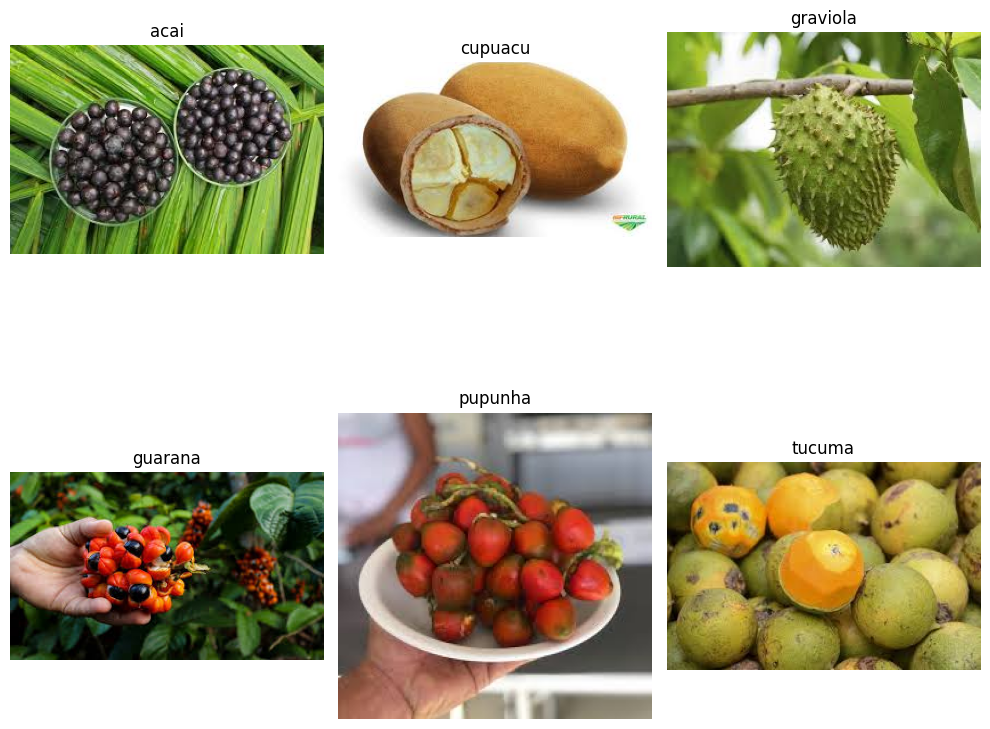


Observation: The images are varied and each subdirectory corresponds to a specific fruit class. The visualization confirms the data organization for training.


In [22]:
# 1. Load and visualize images from a dataset

class_names = sorted([name for name in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, name))])
num_classes = len(class_names)

print(f"Found {num_classes} classes: {class_names}")

if num_classes == 0:
    print("No class subdirectories found in the training directory. Please check your data structure.")
else:
    plt.figure(figsize=(10, 10))
    for i, class_name in enumerate(class_names):
        class_path = os.path.join(TRAIN_DIR, class_name)
        images_in_class = os.listdir(class_path)

        if not images_in_class:
            print(f"Warning: No images found in class directory: {class_path}")
            continue

        random_img_name = random.choice(images_in_class)
        img_path = os.path.join(class_path, random_img_name)
        img = Image.open(img_path)

        ax = plt.subplot(2, (num_classes + 1) // 2, i + 1) # Arrange in 2 rows
        plt.imshow(img)
        plt.title(class_name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

    print("\nObservation: The images are varied and each subdirectory corresponds to a specific fruit class. The visualization confirms the data organization for training.")


In [23]:
# 2. Check for Corrupted Images

corrupted_images = []

for class_name in class_names:
    class_path = os.path.join(TRAIN_DIR, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            img = Image.open(img_path)
            img.verify() # Verify if it's a valid image
            img.close() # Close to release file handle
        except (IOError, SyntaxError) as e:
            corrupted_images.append(img_path)
            print(f"Removed corrupted image: {img_path} (Error: {e})")
            os.remove(img_path) # Remove the corrupted file

if not corrupted_images:
    print("No corrupted images found.")
else:
    print(f"\nTotal corrupted images removed: {len(corrupted_images)}")


No corrupted images found.


### Task 2: Loading and Preprocessing Image Data in Keras

This section uses Keras' `image_dataset_from_directory` to load the images, apply resizing, batching, and normalization for both training and validation datasets.

In [24]:
# Define image size and batch size
img_height = 128
img_width = 128
batch_size = 32
validation_split = 0.2 # 80% training, 20% validation
seed = 123 # For reproducibility

# Create a preprocessing layer for normalization
rescale = tf.keras.layers.Rescaling(1./255) # Normalize pixel values to [0, 1]

# Create training dataset with normalization
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=seed
)

# Apply the normalization (Rescaling) to the dataset
train_ds = train_ds.map(lambda x, y: (rescale(x), y))

# Create validation dataset with normalization
val_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # No need to shuffle validation data
    validation_split=validation_split,
    subset='validation',
    seed=seed
)

# Apply the normalization (Rescaling) to the validation dataset
val_ds = val_ds.map(lambda x, y: (rescale(x), y))

# Create test dataset (assuming a separate test directory)
test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR, # Use the separate test directory
    labels='inferred',
    label_mode='int',
    image_size=(img_height, img_width),
    interpolation='nearest',
    batch_size=batch_size,
    shuffle=False, # No need to shuffle test data
    seed=seed # Use seed for consistency if needed, though shuffle is False
)

# Apply the normalization to the test dataset
test_ds = test_ds.map(lambda x, y: (rescale(x), y))

# Configure dataset for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Get the number of classes from the training dataset
num_classes = len(train_ds.class_names)
print(f"Number of classes after preprocessing: {num_classes}")
print(f"Class names: {train_ds.class_names}")



Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.
Found 30 files belonging to 6 classes.


AttributeError: '_PrefetchDataset' object has no attribute 'class_names'

### Task 3: Implement a CNN with Specified Architecture

This section defines the Convolutional Neural Network model using the architecture provided in the worksheet.

In [25]:
# Define a simple CNN model based on the worksheet's architecture
model = keras.Sequential([
    # Input layer will be implicitly defined by the first Conv2D's input_shape
    # Convolutional Layer 1
    layers.Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(img_height, img_width, 3)), # Assuming 3 channels for color images
    # Pooling Layer 1
    layers.MaxPooling2D((2, 2), strides=2),

    # Convolutional Layer 2
    layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
    # Pooling Layer 2
    layers.MaxPooling2D((2, 2), strides=2),

    # Flatten Layer
    layers.Flatten(),

    # Fully Connected Network Architecture
    # Hidden Layer - 1 (Input Layer to FCN conceptually, though not explicitly named as such in problem)
    layers.Dense(128, activation='relu'),
    # Hidden Layer - 2
    layers.Dense(64, activation='relu'),
    # Output Layer
    layers.Dense(num_classes, activation='softmax') # num_classes based on dataset
])

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,213,222 (16.07 MB)

 Trainable params: 4,213,222 (16.07 MB)

 Non-trainable params: 0 (0.00 B)

### Task 4: Compile the Model

Here, the model is configured for training by specifying the optimizer, loss function, and evaluation metrics.

In [26]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', # Use sparse_categorical_crossentropy for integer labels
    metrics=['accuracy']
)


### Task 5: Train the Model

The model is trained using the `model.fit()` function, incorporating `ModelCheckpoint` to save the best model and `EarlyStopping` to prevent overfitting.

In [27]:
# Define callbacks for training
checkpoint_filepath = 'best_cnn_model.h5'
model_checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_filepath,
    save_weights_only=False, # Save the entire model
    monitor='val_accuracy',
    mode='max',
    save_best_only=True
)

early_stopping_callback = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=10, # Number of epochs with no improvement after which training will be stopped.
    restore_best_weights=True
)

epochs = 50 # Using a smaller number of epochs for demonstration; worksheet asks for 250

history = model.fit(
    train_ds,
    epochs=epochs,
    batch_size=16, # Worksheet specifies batch_size to 16 for fit() call
    validation_data=val_ds,
    callbacks=[model_checkpoint_callback, early_stopping_callback]
)

print(f"\nTraining finished. Best model saved to {checkpoint_filepath}")


Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step - accuracy: 0.1858 - loss: 2.2597

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 668ms/step - accuracy: 0.1667 - loss: 2.4608 - val_accuracy: 0.0000e+00 - val_loss: 2.7015
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 728ms/step - accuracy: 0.2083 - loss: 1.8677 - val_accuracy: 0.0000e+00 - val_loss: 1.8234
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 735ms/step - accuracy: 0.2992 - loss: 1.6136

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.3194 - loss: 1.5945 - val_accuracy: 0.3333 - val_loss: 1.6009
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 575ms/step - accuracy: 0.5145 - loss: 1.4445

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 714ms/step - accuracy: 0.5278 - loss: 1.3991 - val_accuracy: 0.6667 - val_loss: 1.3701
Epoch 5/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 400ms/step - accuracy: 0.6100 - loss: 1.1770

3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 526ms/step - accuracy: 0.6111 - loss: 1.1310 - val_accuracy: 0.8333 - val_loss: 0.7589
Epoch 6/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 479ms/step - accuracy: 0.7639 - loss: 0.7952 - val_accuracy: 0.7222 - val_loss: 0.8522
Epoch 7/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.8189 - loss: 0.5829

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 690ms/step - accuracy: 0.8472 - loss: 0.5185 - val_accuracy: 0.9444 - val_loss: 0.4003
Epoch 8/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 801ms/step - accuracy: 0.8750 - loss: 0.3710 - val_accuracy: 0.5556 - val_loss: 0.8883
Epoch 9/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 702ms/step - accuracy: 0.9444 - loss: 0.2457 - val_accuracy: 0.8889 - val_loss: 0.4086
Epoch 10/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 455ms/step - accuracy: 0.9028 - loss: 0.2741 - val_accuracy: 0.5000 - val_loss: 1.3600
Epoch 11/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 473ms/step - accuracy: 0.8889 - loss: 0.2110 - val_accuracy: 0.8889 - val_loss: 0.2794
Epoch 12/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 461ms/step - accuracy: 1.0000 - loss: 0.1067 - val_accuracy: 0.8889 - val_loss: 0.3246
Epoch 13/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 451ms/step - accuracy: 1.0000 - loss: 0.0700 - val_accuracy: 0.8889 - val_loss: 0.3125
Epoch 14/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 435ms/step - accuracy: 1.0000 - loss: 0.0246 - val_accuracy: 0.7778 - val_loss: 0.429

### Model Training Visualization

Plotting the training and validation loss and accuracy to visualize the model's learning progress.

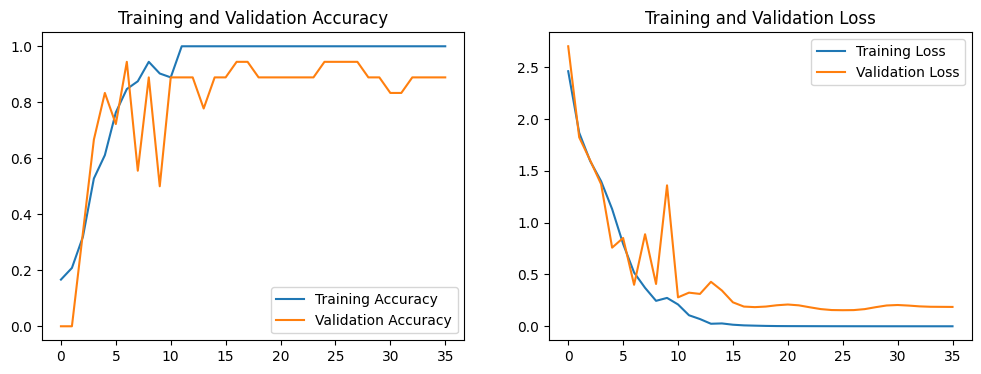

In [28]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(len(acc))

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


### Task 6: Evaluate the Model

The trained model is evaluated on the test dataset to assess its performance on unseen data.

In [29]:
# Evaluate the model on the test set
print("\nEvaluating the model on the test dataset...")
test_loss, test_acc = model.evaluate(test_ds)
print(f"Test accuracy: {test_acc:.4f}")
print(f"Test loss: {test_loss:.4f}")



Evaluating the model on the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step - accuracy: 0.6333 - loss: 1.1887
Test accuracy: 0.6333
Test loss: 1.1887


### Task 7: Save and Load the Model

Demonstrates how to save the trained model to an `.h5` file and then load it back into memory for further use or evaluation.

In [30]:
# Save the trained model (already done by ModelCheckpoint, but demonstrating explicitly)
model_save_path = 'final_cnn_model.h5'
model.save(model_save_path)
print(f"Model saved to {model_save_path}")

# Load the saved model
loaded_model = tf.keras.models.load_model(model_save_path)
print(f"Model loaded from {model_save_path}")

# Re-evaluate the loaded model on the test set to confirm it works
print("\nRe-evaluating the loaded model on the test dataset...")
loaded_test_loss, loaded_test_acc = loaded_model.evaluate(test_ds)
print(f"Loaded model test accuracy: {loaded_test_acc:.4f}")
print(f"Loaded model test loss: {loaded_test_loss:.4f}")


Model saved to final_cnn_model.h5
Model loaded from final_cnn_model.h5

Re-evaluating the loaded model on the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 777ms/step - accuracy: 0.6333 - loss: 1.1887
Loaded model test accuracy: 0.6333
Loaded model test loss: 1.1887


### Task 8: Predictions and Classification Report

This final section makes predictions on the test images and generates a detailed classification report to analyze the model's performance per class.

In [33]:
# Note: We use the 'class_names' list generated during Task 1 or 2
# to avoid the AttributeError from the PrefetchDataset object.

# Make predictions on test images
print("\nMaking predictions on the test dataset...")
y_pred_probabilities = loaded_model.predict(test_ds)
y_pred_labels = np.argmax(y_pred_probabilities, axis=1)

# Get true labels from the test dataset
y_true_labels = np.concatenate([y for x, y in test_ds], axis=0)

# Generate classification report
print("\nClassification Report:")
# Use the class_names variable we defined earlier in the notebook
print(classification_report(y_true_labels, y_pred_labels, target_names=class_names))


Making predictions on the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 167ms/step

Classification Report:
              precision    recall  f1-score   support

        acai       0.50      0.80      0.62         5
     cupuacu       0.60      0.60      0.60         5
    graviola       0.71      1.00      0.83         5
     guarana       0.67      0.40      0.50         5
     pupunha       0.67      0.80      0.73         5
      tucuma       1.00      0.20      0.33         5

    accuracy                           0.63        30
   macro avg       0.69      0.63      0.60        30
weighted avg       0.69      0.63      0.60        30

